<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex08_RNN_%EA%B3%84%EC%97%B4_%EC%9D%B4%ED%95%B4%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 네이버 영화 리뷰 데이터 감성 분석 -> RNN 계열 모델 활용
- 긍정, 부정(이진분류) 데이터셋

In [23]:
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


In [22]:
# 데이터 불러오기 -> DF로 저장
# train_df, test_df
import pandas as pd
train_df = pd.read_csv("./data/ratings_train.txt", delimiter="\t")
test_df = pd.read_csv("./data/ratings_test.txt", delimiter="\t")

In [25]:
test_df

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0
...,...,...,...
49995,4608761,오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함,1
49996,5308387,의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따 OOOO,0
49997,9072549,그림도 좋고 완성도도 높았지만... 보는 내내 불안하게 만든다,0
49998,5802125,절대 봐서는 안 될 영화.. 재미도 없고 기분만 잡치고.. 한 세트장에서 다 해먹네,0


In [26]:
# 데이터 결측치 제거해서 원본 데이터에 반영
train_df.dropna(inplace=True)
test_df = test_df.dropna()

In [27]:
# 정규표현식 사용해서 특수문자 제거
# 영어 대소문자, 한글, ?, !, ., 띄어쓰기 한 개 보존
# 나머지 특수문자 제거
# 함수로 만들어 전체 데이터에 적용하기
import re
pattern = re.compile(r"[^a-zA-Z0-9가-힣\s\.\?\!]")

# doc_train = train_df["document"]
# doc_test = test_df["document"]

# from tqdm import tqdm

# new_doc_train = []
# for doc in tqdm(doc_train) :
#   clean_doc_train = re.sub(pattern, "", doc) # 해당 패턴에 해당하는 부분을 삭제
#   new_doc_train.append(clean_doc_train)

# new_doc_test = []
# for doc in tqdm(doc_test) :
#   clean_doc_test = re.sub(pattern, "", doc) # 해당 패턴에 해당하는 부분을 삭제
#   new_doc_test.append(clean_doc_test)

# train_df["cleaned_doc"] = new_doc_train
# test_df["cleaned_doc"] = new_doc_test

In [28]:
# 형태소 분석 -> kiwi에서 제공하는 불용어 리스트 반영해서 okt 사용해서 형태소 분석
# 어간 추출, 정규화, 불용어 제거, (명사, 동사, 형용사)를 제외한 품사들은 모두 제거

# !pip install kiwipiepy
# !pip install konlpy
from kiwipiepy import Kiwi
kiwi = Kiwi()
from konlpy.tag import Okt
okt = Okt()
from kiwipiepy.utils import Stopwords
stopwords = Stopwords()
# print로 찍어보면, 튜플 형식으로 되어 있는데 첫 번째 요소들만 뽑아서 쓰기
# print(stopwords.stopwords)

stopwords_list = [word for word, tag in stopwords.stopwords]

# print(okt.tagset)

# rv_train = train_df["cleaned_doc"]

# total_okt = []

# for doc in tqdm(rv_train) :
#   result = okt.pos(doc, stem=True)
#   temp = [] # 행별로 유의미한 토큰들을 담을 리스트
#   for word, tag in result :
#     if tag in ["Noun", "Verb", "Adjective"] :
#       temp.append(word)
#   total_okt.append(temp)

def preprocessing_text(text) :
  # 1. 특수문자 제거 -> 소문자화 -> 양끝 공백 제거
  text = re.sub(pattern, "", text).lower().strip()

  # 2. 형태소 분석(어간 추출, 정규화)
  pos_tags = okt.pos(text, stem = True, norm = True)

  # 불용어 리스트에 들어있는지 확인 + 우리가 원하는 품사인지 확인
  tokens = []
  for w, t in pos_tags:
    if t in ("Noun", "Verb", "Adjective") and w not in stopwords_list:
      tokens.append(w)

  return " ".join(tokens) # 전처리 완료된 단어들을 공백으로 이어서 문자열로 반환

In [29]:
# 판다스에서 제공하는 apply + tqdm 함수 -> 시리즈 전체에 함수를 적용하면서 진행률을 보여주는 함수
# 판다스 버전이 바뀌면서 안 됨...
X_train_clean = train_df["document"].apply(preprocessing_text)
X_test_clean = test_df["document"].apply(preprocessing_text)

In [23]:
# 정답 데이터 분리 train_df, test_df에서 정답(긍정, 부정) -> y_train, y_test 변수에 저장
y_train = train_df["label"]
y_test = test_df["label"]

### 전처리 완료된 데이터 저장

In [31]:
import pickle

with open("./data/X_train_morphs.pkl", "wb") as f :
  pickle.dump(X_train_clean, f)

with open("./data/X_test_morphs.pkl", "wb") as f :
  pickle.dump(X_test_clean, f)

with open("./data/y_train_morphs.pkl", "wb") as f :
  pickle.dump(y_train, f)

with open("./data/y_test_morphs.pkl", "wb") as f :
  pickle.dump(y_test, f)

### 다음 실습에서는 여기부터 진행

In [1]:
# 구글 드라이브 연동
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 작업 경로 변경
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


In [3]:
import numpy as np
import pandas as pd
import pickle

In [4]:
# 저장한 전처리 완료 데이터 불러오기
with open("./data/X_train_morphs.pkl", "rb") as f :
  X_train_clean = pickle.load(f)

with open("./data/X_test_morphs.pkl", "rb") as f :
  X_test_clean = pickle.load(f)

with open("./data/y_train_morphs.pkl", "rb") as f :
  y_train_clean = pickle.load(f)

with open("./data/y_test_morphs.pkl", "rb") as f :
  y_test_clean = pickle.load(f)

### 문자열 -> 수치 변환

In [5]:
from tensorflow.keras.layers import TextVectorization
# 텍스트 데이터를 수치데이터(벡터)로 변경

In [6]:
vectorizer = TextVectorization(
    max_tokens = 5000,                          # 사전에서 사용할 최대 단어 수를 결정
                                                # 최대 5000개의 단어를 사용해 단어 사전을 만들고 그 단어 사전을 바탕으로 단어를 인덱스로 변환
    output_mode = "int",                        # 텍스트를 정수 인덱스로 변환
    output_sequence_length = 10,                # 출력되는 정수 벡터 길이를 고정(길면 자르고, 짧으면 채움)
    standardize = "lower_and_strip_punctuation"  # 텍스트 데이터를 표준화하는 방식 지정(소문자, 구두점 제거)
)

In [7]:
X_train_clean

,document
0,더빙 진짜 짜증나다 목소리
1,흠 포스터 보고 초딩 영화 줄 오버 연기 가볍다 않다
2,무재 밓었 다그 래서 보다 추천
3,교도소 이야기 구먼 솔직하다 재미 없다 평점 조정
4,몬페 익살스럽다 연기 돋보이다 영화 스파이더맨 늙다 보이다 하다 커스틴 던스트 이쁘...
...,...
149995,인간 문제 소 죄인
149996,평점 낮다
149997,뭐 한국인 거들다 먹거리 필리핀 혼혈 착하다
149998,청춘 영화 최고봉 방황 우울하다 날 자화상


In [8]:
# 단어사전 구축
vectorizer.adapt(X_train_clean)

In [9]:
# 단어사전에 들어간 단어의 수 확인
vectorizer.vocabulary_size()

5000

In [10]:
print(vectorizer.get_vocabulary())
# UNK : 단어사전에 등록되지 않은 단어를 표현하는 토큰(unknown)

['', '[UNK]', np.str_('영화'), np.str_('하다'), np.str_('보다'), np.str_('없다'), np.str_('있다'), np.str_('좋다'), np.str_('재밌다'), np.str_('정말'), np.str_('되다'), np.str_('진짜'), np.str_('같다'), np.str_('이다'), np.str_('점'), np.str_('아니다'), np.str_('않다'), np.str_('만들다'), np.str_('나오다'), np.str_('연기'), np.str_('평점'), np.str_('최고'), np.str_('왜'), np.str_('스토리'), np.str_('생각'), np.str_('드라마'), np.str_('감동'), np.str_('보고'), np.str_('아깝다'), np.str_('이렇다'), np.str_('배우'), np.str_('내'), np.str_('재미있다'), np.str_('거'), np.str_('감독'), np.str_('뭐'), np.str_('재미'), np.str_('내용'), np.str_('그냥'), np.str_('주다'), np.str_('재미없다'), np.str_('좀'), np.str_('자다'), np.str_('지루하다'), np.str_('쓰레기'), np.str_('시간'), np.str_('가다'), np.str_('모르다'), np.str_('들다'), np.str_('그렇다'), np.str_('싶다'), np.str_('작품'), np.str_('알다'), np.str_('사랑'), np.str_('하나'), np.str_('다시'), np.str_('볼'), np.str_('마지막'), np.str_('오다'), np.str_('처음'), np.str_('완전'), np.str_('정도'), np.str_('많다'), np.str_('장면'), np.str_('액션'), np.str_('주인공'), np.str_('차다'),

In [11]:
X_train_vec = vectorizer(X_train_clean)
# 데이터를 단어사전을 바탕으로 수치화를 진행

In [12]:
X_train_clean.shape, X_train_vec.shape

((149995,), TensorShape([149995, 10]))

In [13]:
print(X_train_clean[0])
print(X_train_vec[0])
# array의 형태로 단어에 매핑된 정수들이 들어있음 -> 길이가 짧아서 0으로 패딩을 넣어놓음

더빙 진짜 짜증나다 목소리
tf.Tensor([341  11 162 505   0   0   0   0   0   0], shape=(10,), dtype=int64)


In [14]:
# 테스트 데이터도 벡터화 진행
X_test_vec = vectorizer(X_test_clean)
X_test_vec.shape

TensorShape([49997, 10])

In [15]:
# RNN모델은 (샘플 개수, 시퀀스 길이, 특성 차원) 형태로 입력을 받음
X_train_vec = np.expand_dims(X_train_vec, -1) # -1 : 마지막 축에 새로운 차원을 추가
X_test_vec = np.expand_dims(X_test_vec, -1)

In [16]:
X_train_vec.shape, X_test_vec.shape

((149995, 10, 1), (49997, 10, 1))

### 모델링

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, SimpleRNN, Dense

In [18]:
model = Sequential()

model.add(InputLayer(shape=(10, 1))) # 시퀀스 길이, 입력 특성

model.add(SimpleRNN(units=64))

model.add(Dense(units=1, activation="sigmoid")) # 긍정/부정 이진분류 수행

In [19]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [24]:
his_simple = model.fit(
    X_train_vec, y_train,
    epochs = 40,
    batch_size = 128,
    validation_split = 0.2
)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5009 - loss: 0.6965 - val_accuracy: 0.5035 - val_loss: 0.6944
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4987 - loss: 0.6952 - val_accuracy: 0.4982 - val_loss: 0.6945
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5012 - loss: 0.6947 - val_accuracy: 0.4951 - val_loss: 0.6965
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5004 - loss: 0.6946 - val_accuracy: 0.5017 - val_loss: 0.6939
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5049 - loss: 0.6945 - val_accuracy: 0.5014 - val_loss: 0.6937
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5023 - loss: 0.6942 - val_accuracy: 0.5009 - val_loss: 0.6950
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5029 - loss: 0.6940 - val_accuracy: 0.4978 - val_loss: 0.6950
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5003 - loss: 0.6944 - val_accuracy: 0.

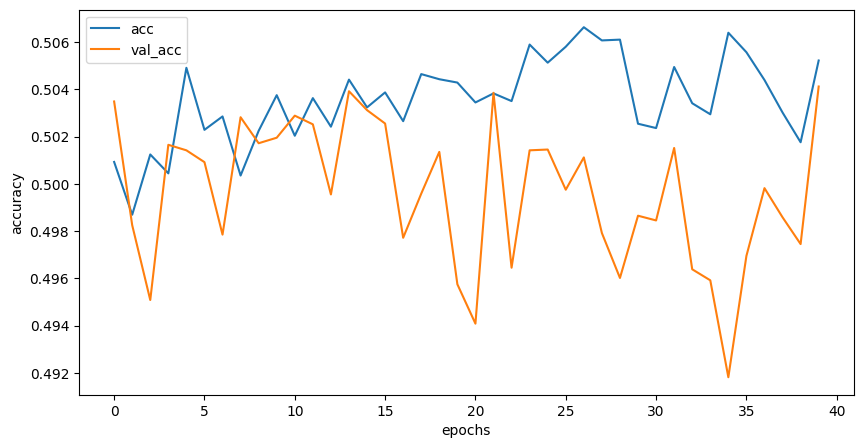

In [25]:
# 학습 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(his_simple.history["accuracy"], label="acc")
plt.plot(his_simple.history["val_accuracy"], label="val_acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

### SimpleRNN의 경우 긴 시퀀스를 가진 데이터를 효과적으로 학습하기 어려움

- 순환 횟수(시퀀스)가 길어질수록 초반에 입력된 단어의 기억 데이터가 소실되는 현상이 발생
- 문장 구성 시 초반 단어가 후반 계산에 영향을 주는 경우는 simple RNN이 학습하기 어려움

### LSTM
- 장기기억과 단기기억을 관리하는 계산이 추가된 LSTM이 등장
- 기울기 소실 문제를 해결하기 위해 cell과 여러 게이트(Forget, Input, output)를 사용해서 정보를 선택적으로 기억하거나 잊음
- 긴 시퀀스 데이터를 처리할 때 유리

![image](https://user-images.githubusercontent.com/1250095/40670602-b1d0211a-63a4-11e8-9abc-a5de1f90a547.png)

### GRU
- LSTM보다 간단한 구조의 순환 신경망(RNN) 계열의 또 다른 모델
- LSTM의 모든 기능을 포함하면서도 좀더 가볍고 빠름
- cell -> hidden state만 사용
- reset, update 게이트만을 사용해서 정보를 관리
- 학습 속도가 빠르고 성능도 LSTM과 비슷한 경우가 많음

![image](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcWUO6M%2FbtqOSxbT285%2FAAAAAAAAAAAAAAAAAAAAAEpjlo7q0u8szumdLmyDJnwwVzuMnoBdl86og-bkJC2g%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1777561199%26allow_ip%3D%26allow_referer%3D%26signature%3Dxcnz0R1Tl1cgeRmjTUC3Mm%252BDxvw%253D)

In [26]:
from tensorflow.keras.layers import LSTM, GRU

In [27]:
# LSTM 모델 설계
LSTM_model = Sequential()

LSTM_model.add(InputLayer(shape=(10, 1)))
LSTM_model.add(LSTM(units=64))
LSTM_model.add(Dense(units=1, activation="sigmoid"))

LSTM_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

his_LSTM = LSTM_model.fit(
    X_train_vec, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=128
)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5054 - loss: 0.6938 - val_accuracy: 0.4982 - val_loss: 0.6937
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5063 - loss: 0.6935 - val_accuracy: 0.4960 - val_loss: 0.6937
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5063 - loss: 0.6933 - val_accuracy: 0.4970 - val_loss: 0.6943
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5048 - loss: 0.6933 - val_accuracy: 0.4972 - val_loss: 0.6936
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5072 - loss: 0.6931 - val_accuracy: 0.4992 - val_loss: 0.6938
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5072 - loss: 0.6931 - val_accuracy: 0.4950 - val_loss: 0.6938
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6941
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5093 - loss: 0.6930 - val_accuracy: 0

In [29]:
# GRU 모델 설계
GRU_model = Sequential()

GRU_model.add(InputLayer(shape=(10, 1)))
GRU_model.add(GRU(units=64))
GRU_model.add(Dense(units=1, activation="sigmoid"))

GRU_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

his_GRU = GRU_model.fit(
    X_train_vec, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=128
)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5044 - loss: 0.6942 - val_accuracy: 0.4926 - val_loss: 0.6939
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5066 - loss: 0.6935 - val_accuracy: 0.4990 - val_loss: 0.6945
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5085 - loss: 0.6933 - val_accuracy: 0.5019 - val_loss: 0.6939
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5080 - loss: 0.6932 - val_accuracy: 0.4976 - val_loss: 0.6939
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5068 - loss: 0.6933 - val_accuracy: 0.4934 - val_loss: 0.6955
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5076 - loss: 0.6931 - val_accuracy: 0.4977 - val_loss: 0.6939
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5080 - loss: 0.6931 - val_accuracy: 0.4961 - val_loss: 0.6938
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5092 - loss: 0.6931 - val_accuracy: 0.

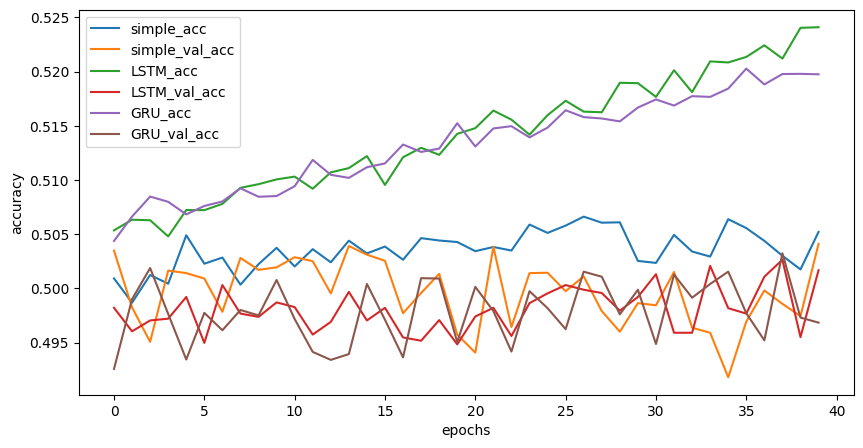

In [31]:
# 학습 결과 시각화

plt.figure(figsize=(10,5))
plt.plot(his_simple.history["accuracy"], label="simple_acc")
plt.plot(his_simple.history["val_accuracy"], label="simple_val_acc")
plt.plot(his_LSTM.history["accuracy"], label="LSTM_acc")
plt.plot(his_LSTM.history["val_accuracy"], label="LSTM_val_acc")
plt.plot(his_GRU.history["accuracy"], label="GRU_acc")
plt.plot(his_GRU.history["val_accuracy"], label="GRU_val_acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()